# Proyecto de Regresión Lineal - Coste del Seguro Médico

## Objetivo

En este proyecto construiremos un modelo de regresión lineal capaz de predecir el coste del seguro médico (`charges`) de un cliente a partir de sus características personales.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


In [2]:
# Cargamos el dataset
df = pd.read_csv("../data/raw/medical_insurance_cost.csv")

In [3]:
df.head()



,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


##El dataset contiene 1338 registros y 7 columnas.
No existen valores nulos, por lo que inicialmente no será necesario tratar datos faltantes.
Hay 4 variables numéricas (age, bmi, children y charges) y 3 variables categóricas (sex, smoker y region).
La variable objetivo será charges, que representa el coste del seguro médico.
Antes de entrenar el modelo será necesario transformar las variables categóricas en variables numéricas para que la regresión lineal pueda utilizarlas.

In [5]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [6]:
df.duplicated().sum()

np.int64(1)

In [7]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()


np.int64(0)

In [10]:
df.dtypes


age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

El dataset contiene 7 variables. Cuatro son numéricas (age, children, bmi y charges) y tres son categóricas (sex, smoker y region). Las variables categóricas deberán transformarse a formato numérico antes de entrenar un modelo de Machine Learning.

In [11]:
df["sex"].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [12]:
df["smoker"].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [13]:
df["region"].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

## Comienza el eda


## Variables categoricas


In [14]:
# Función para analizar variables categóricas
def analizar_categorica(df, columna):

    conteo = df[columna].value_counts()

    print(conteo)

    conteo.plot(kind="bar")

    plt.title(f"Distribución de la variable '{columna}'")
    plt.xlabel(columna)
    plt.ylabel("Número de clientes")

    plt.show()

sex
male      675
female    662
Name: count, dtype: int64


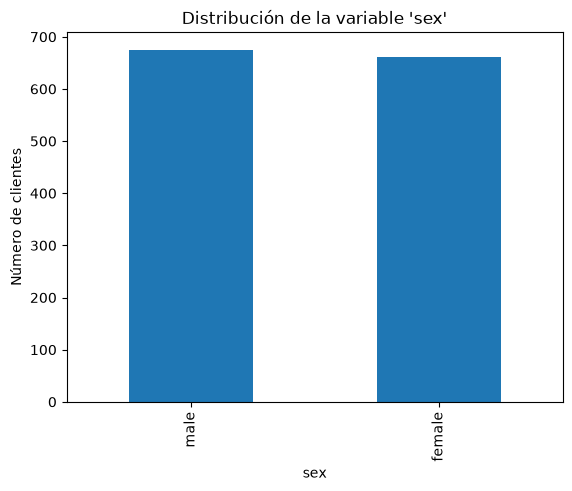

In [15]:
analizar_categorica(df, "sex")

smoker
no     1063
yes     274
Name: count, dtype: int64


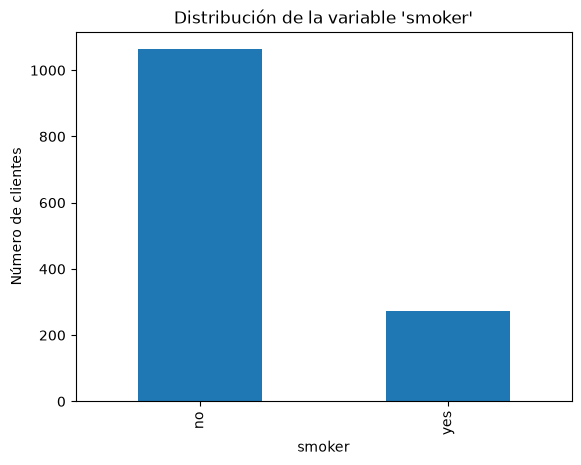

In [16]:
analizar_categorica(df, "smoker")


region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


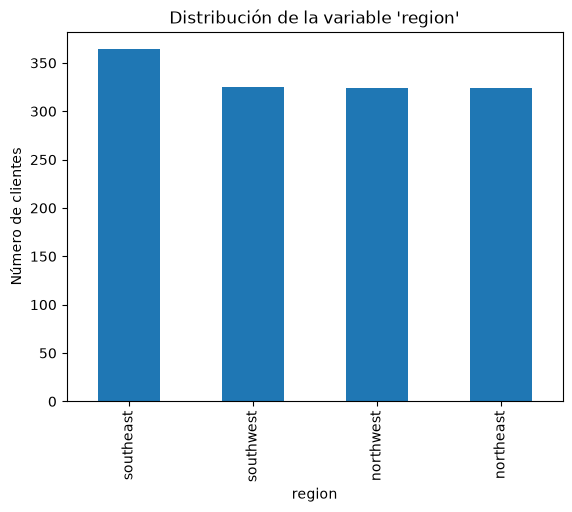

In [17]:
analizar_categorica(df, "region")

## variables numerica

In [18]:
# Función para analizar variables numéricas
def analizar_numerica(df, columna):

    fig, ax = plt.subplots(1, 2, figsize=(14,4))

    # Histograma
    sns.histplot(df[columna], kde=True, ax=ax[0])
    ax[0].set_title(f"Distribución de '{columna}'")

    # Boxplot
    sns.boxplot(x=df[columna], ax=ax[1])
    ax[1].set_title(f"Boxplot de '{columna}'")

    plt.tight_layout()
    plt.show()

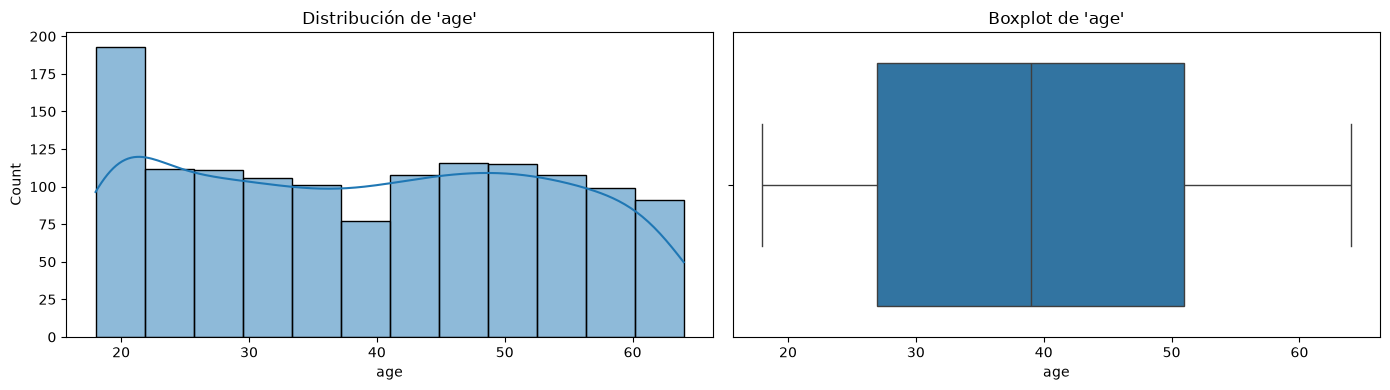

In [19]:
analizar_numerica(df, "age")

La variable age presenta una distribución bastante equilibrada entre los 18 y los 64 años, aunque se observa un ligero pico alrededor de los 20 años. En el boxplot no se identifican valores atípicos, por lo que no parece haber edades fuera del rango esperado. Como hipótesis de negocio, es razonable pensar que la edad pueda influir en el coste del seguro médico, aunque esta relación deberá comprobarse más adelante mediante un análisis bivariante.

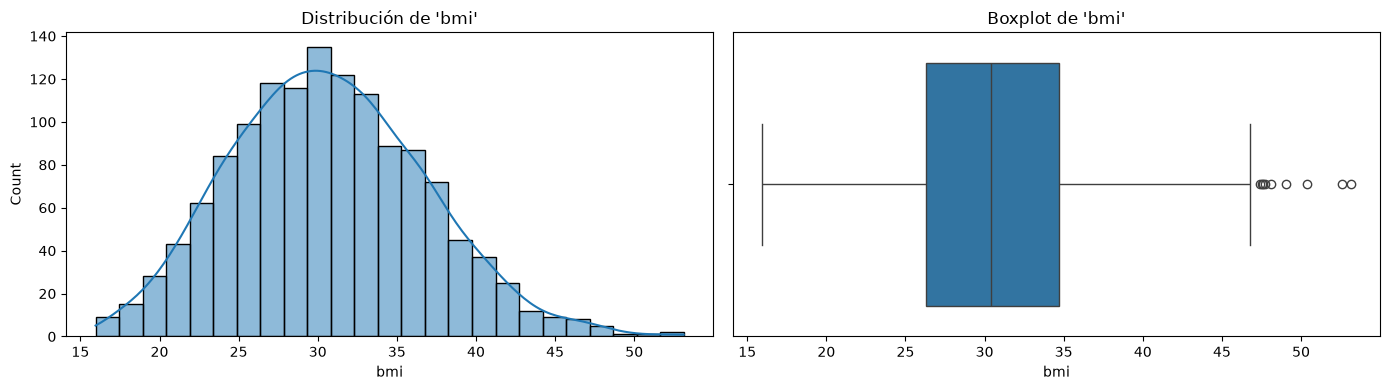

In [20]:
analizar_numerica(df, "bmi")

La variable bmi presenta una distribución aproximadamente normal con un ligero sesgo hacia la derecha. El boxplot muestra la presencia de varios valores atípicos, correspondientes a personas con un índice de masa corporal superior al habitual. Como hipótesis de negocio, es posible que el BMI influya en el coste del seguro médico, aunque esta relación deberá confirmarse en el análisis bivariante.

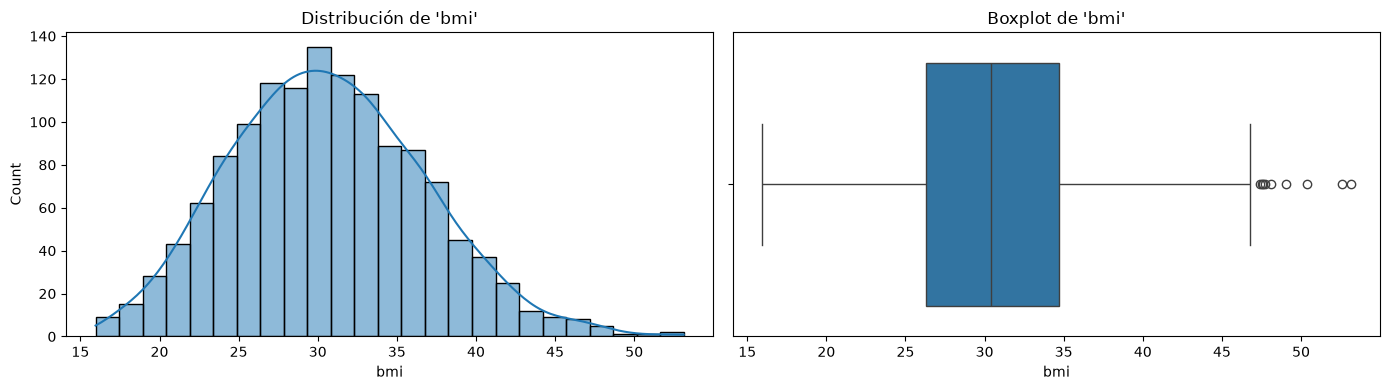

In [21]:
analizar_numerica(df, "bmi")

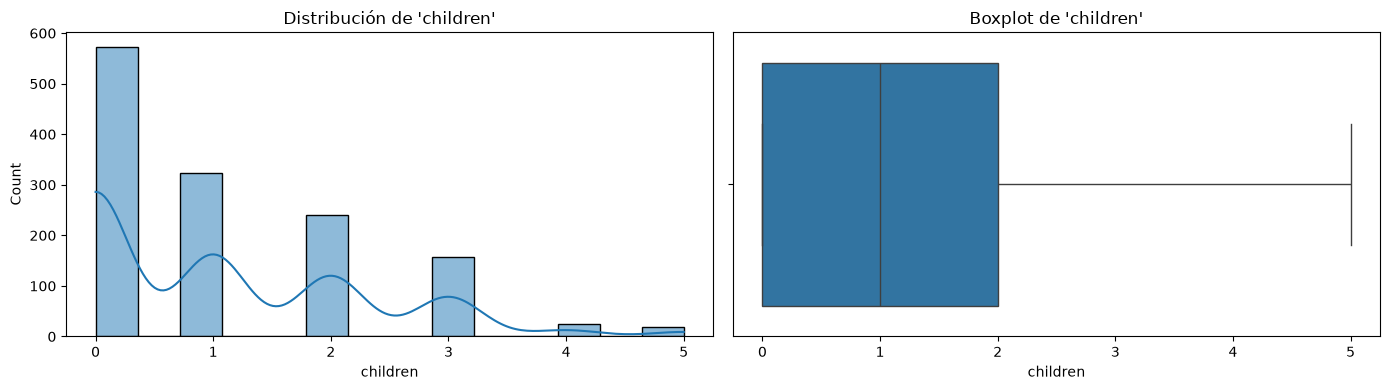

In [22]:
analizar_numerica(df, "children")

La variable children presenta una distribución claramente asimétrica hacia la derecha. La mayoría de los clientes no tienen hijos, y a medida que aumenta el número de hijos, disminuye la frecuencia de clientes en el dataset.No se observan valores atipicos

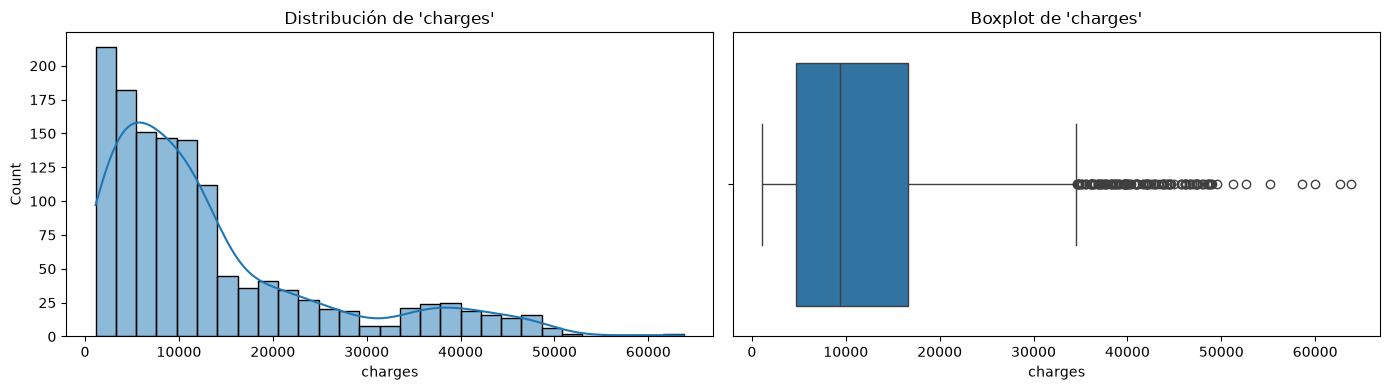

In [23]:
analizar_numerica(df, "charges")

La variable charges presenta una distribución claramente asimétrica con un fuerte sesgo hacia la derecha. La mayoría de los clientes tienen costes relativamente bajos, mientras que existe un grupo reducido con costes muy elevados. Además, el boxplot muestra la presencia de numerosos valores atípicos (outliers), correspondientes a clientes con gastos significativamente superiores al resto.

## Analisis bivariante usando la variable "charges" con las demas( es la buscada)


In [24]:
# Función para analizar la relación entre dos variables numéricas
def analizar_relacion_numerica(df, x, y):

    plt.figure(figsize=(8, 5))

    sns.regplot(
        data=df,
        x=x,
        y=y,
        scatter_kws={"alpha": 0.5},
        line_kws={"color": "red"}
    )

    plt.title(f"Relación entre {x} y {y}")
    plt.xlabel(x)
    plt.ylabel(y)

    plt.show()

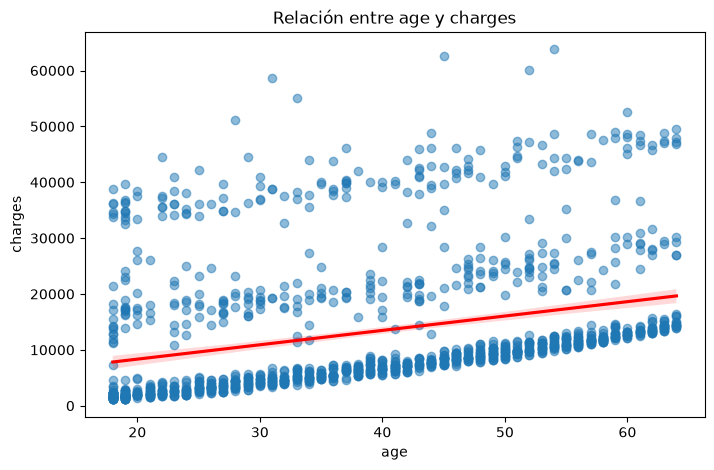

In [25]:
analizar_relacion_numerica(df, "age", "charges")

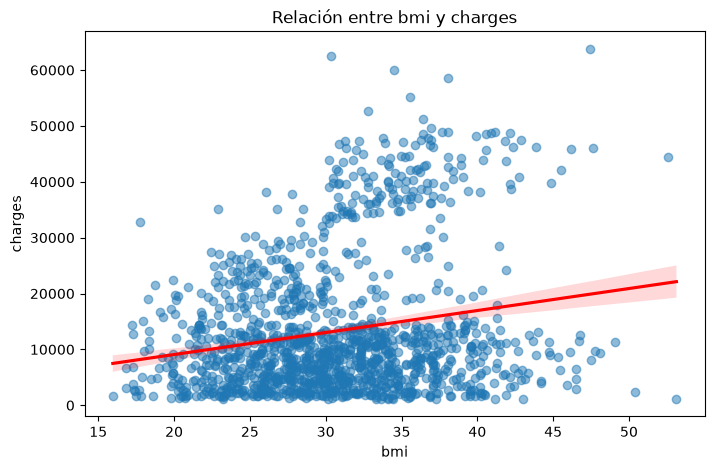

In [26]:
analizar_relacion_numerica(df, "bmi", "charges")

<Axes: xlabel='children', ylabel='charges'>

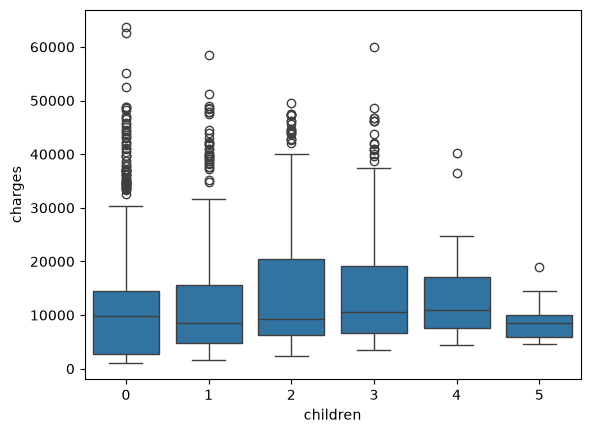

In [27]:
sns.boxplot(data=df, x="children", y="charges")

A simple vista, no se observan diferencias muy marcadas según el número de hijos. Esto sugiere que children podría tener una influencia menor sobre el coste del seguro que otras variables analizadas hasta el momento, aunque esta hipótesis deberá confirmarse con análisis posteriores.

<Axes: xlabel='smoker', ylabel='charges'>

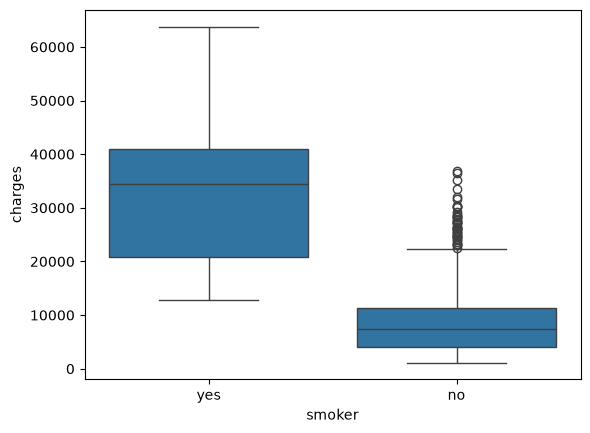

In [28]:
sns.boxplot(data=df, x="smoker", y="charges")

La variable smoker muestra una diferencia muy marcada en los costes del seguro médico. Los clientes fumadores presentan una mediana de charges muy superior a la de los no fumadores. Mientras que en los no fumadores la mediana se sitúa por debajo de los 10.000 dólares anuales, en los fumadores supera los 30.000 dólares. Además, ambos grupos presentan valores atípicos, aunque estos son mucho más elevados en el grupo de fumadores.

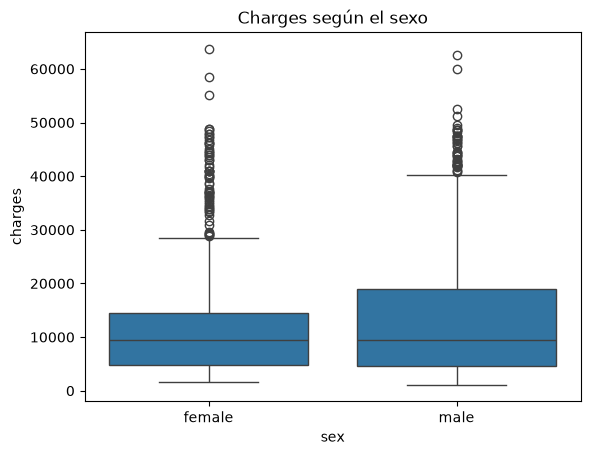

In [29]:
sns.boxplot(data=df, x="sex", y="charges")
plt.title("Charges según el sexo")
plt.show()

La variable sex no muestra diferencias importantes en los costes del seguro médico. La mediana de hombres y mujeres es muy similar, lo que sugiere que el sexo, por sí solo, no parece ser un factor determinante para explicar charges. Se observa una mayor dispersión en el grupo de hombres, aunque esta diferencia no parece suficiente para considerar que el sexo tenga una influencia comparable a la observada en variables como smoker o bmi.

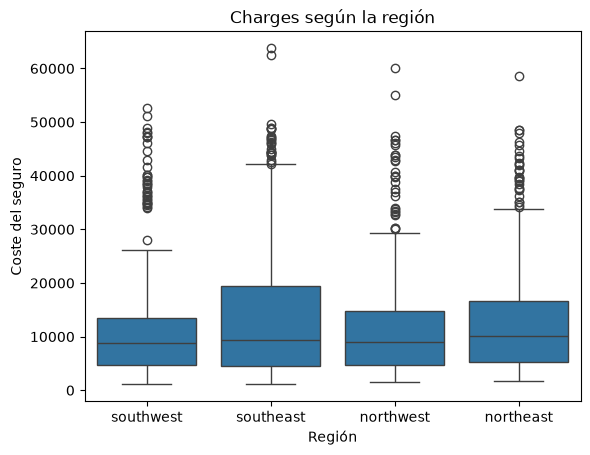

In [30]:
sns.boxplot(data=df, x="region", y="charges")
plt.title("Charges según la región")
plt.xlabel("Región")
plt.ylabel("Coste del seguro")
plt.show()

La variable region no muestra diferencias importantes en la mediana de los costes del seguro, ya que las cuatro regiones presentan valores muy similares. Aunque existen diferencias en la dispersión y aparecen valores atípicos en todas ellas, visualmente no parece que la región sea un factor determinante para explicar charges, especialmente si se compara con el efecto observado en la variable smoker.

In [31]:
pd.factorize(df["sex"])

(array([0, 1, 1, ..., 0, 0, 0], shape=(1337,)),
 Index(['female', 'male'], dtype='str'))

In [32]:
sex_codes, sex_categories = pd.factorize(df["sex"])

In [33]:
sex_codes

array([0, 1, 1, ..., 0, 0, 0], shape=(1337,))

In [34]:
sex_categories

Index(['female', 'male'], dtype='str')

In [35]:
pd.factorize(df["smoker"])

(array([0, 1, 1, ..., 1, 1, 0], shape=(1337,)),
 Index(['yes', 'no'], dtype='str'))

In [36]:
smoker_codes, smoker_categories = pd.factorize(df["smoker"])

In [37]:
pd.factorize(df["region"])

(array([0, 1, 1, ..., 1, 0, 2], shape=(1337,)),
 Index(['southwest', 'southeast', 'northwest', 'northeast'], dtype='str'))

In [38]:
region_codes, region_categories = pd.factorize(df["region"])

In [39]:
df["sex"] = sex_codes
df["smoker"] = smoker_codes
df["region"] = region_codes

In [40]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,0,0,16884.92400
1,18,1,33.770,1,1,1,1725.55230
2,28,1,33.000,3,1,1,4449.46200
3,33,1,22.705,0,1,2,21984.47061
4,32,1,28.880,0,1,2,3866.85520


In [41]:
df.dtypes

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

In [42]:
df.corr()


,age,sex,bmi,children,smoker,region,charges
age,1.000000,-0.019814,0.109344,0.041536,0.025587,-0.001626,0.298308
sex,-0.019814,1.000000,0.046397,0.017848,-0.076596,-0.004936,0.058044
bmi,0.109344,0.046397,1.000000,0.012755,-0.003746,-0.157574,0.198401
children,0.041536,0.017848,0.012755,1.000000,-0.007331,-0.016258,0.067389
smoker,0.025587,-0.076596,-0.003746,-0.007331,1.000000,-0.002358,-0.787234
region,-0.001626,-0.004936,-0.157574,-0.016258,-0.002358,1.000000,0.006547
charges,0.298308,0.058044,0.198401,0.067389,-0.787234,0.006547,1.000000


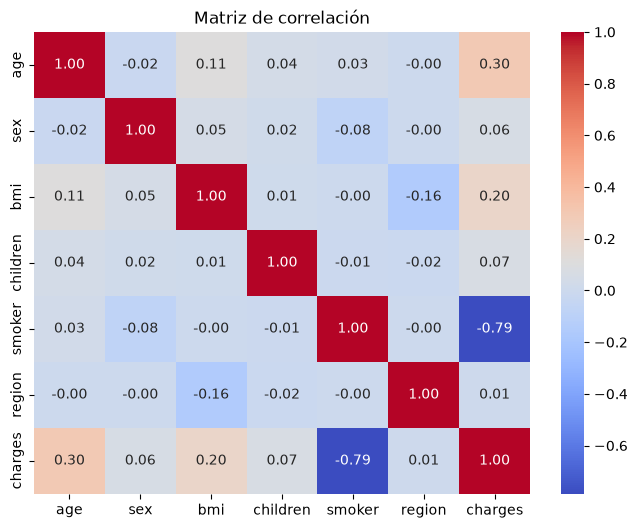

In [43]:


plt.figure(figsize=(8,6))

sns.heatmap(df.corr(),
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Matriz de correlación")
plt.show()

Las variables que muestran una mayor relación con el coste del seguro (charges) son smoker, con diferencia la más influyente, seguida de age y bmi, aunque estas presentan una correlación bastante menor. Por otro lado, children, sex y region muestran correlaciones muy bajas, por lo que, a priori, parecen aportar poca información para explicar el coste del seguro.

## Conclusiones del análisis exploratorio

Después de analizar el dataset, observamos que la variable que presenta una mayor relación con el coste del seguro (`charges`) es `smoker`.

Los clientes fumadores tienen unos costes médicos claramente superiores a los no fumadores. La correlación aparece con signo negativo porque la codificación utilizada asignó `0` a los fumadores y `1` a los no fumadores.

La edad (`age`) y el índice de masa corporal (`bmi`) también muestran una relación positiva con los costes, aunque bastante más moderada.

Las variables `children`, `sex` y `region` presentan una relación mucho menor con `charges`.

Este análisis nos permite formular hipótesis sobre las variables más relevantes, pero será el modelo de regresión lineal y sus métricas quienes nos indiquen la capacidad real de predicción.

# Construcción del modelo de Regresión Lineal

Una vez finalizado el análisis exploratorio de los datos (EDA), comenzamos la fase de Machine Learning.

El objetivo será construir un modelo capaz de predecir el coste del seguro (`charges`) a partir de las características de cada cliente.

Para ello, primero separaremos el conjunto de datos en:

- **Variables predictoras (`X`)**: información que utilizaremos para realizar la predicción.
- **Variable objetivo (`y`)**: valor que queremos que el modelo aprenda a predecir.

A continuación dividiremos los datos en entrenamiento y prueba, entrenaremos el modelo y evaluaremos su capacidad de predicción.

In [44]:
# Separamos las variables predictoras de la variable objetivo

X = df.drop("charges", axis=1)
y = df["charges"]

In [45]:
X.head()

,age,sex,bmi,children,smoker,region
0,19,0,27.900,0,0,0
1,18,1,33.770,1,1,1
2,28,1,33.000,3,1,1
3,33,1,22.705,0,1,2
4,32,1,28.880,0,1,2


In [46]:
y.head()

0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64

## Porque dividir datos de entrenamiento y prueba ?


### "Porque queremos comprobar la capacidad de generalización del modelo. Entrenamos con una parte de los datos para que aprenda los patrones y reservamos otra parte que nunca ha visto para evaluar si realmente sabe predecir nuevos casos y no simplemente memorizar los ejemplos de entrenamiento."

In [47]:
from sklearn.model_selection import train_test_split

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1069, 6)
(268, 6)
(1069,)
(268,)


In [50]:
from sklearn.linear_model import LinearRegression

In [51]:
model = LinearRegression() #creamos la caja 

In [52]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 248.76, -99.7 , 312.61, 534.12,-23052.15, 237.63]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.129e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [53]:
y_pred = model.predict(X_test)


In [54]:
y_pred[:5]

array([ 8080.45018585,  5592.87111988, 14378.29865472, 31731.81954139,
        9158.3569444 ])

In [55]:
y_test[:5]

900      8688.85885
1064     5708.86700
1256    11436.73815
298     38746.35510
237      4463.20510
Name: charges, dtype: float64

In [56]:
# Guardamos una copia del dataset original.
df_CON_outliers = df.copy()

# Creamos otra copia para eliminar los valores atípicos.
df_SIN_outliers = df.copy()

In [57]:
# Columnas que presentan valores atípicos.
outliers_cols = ["age", "bmi", "children", "charges"]

In [58]:
# Función para sustituir los outliers por los límites del rango IQR.
def replace_outliers(column, df):
    col_stats = df[column].describe()
    col_iqr = col_stats["75%"] - col_stats["25%"]

    upper_limit = round(float(col_stats["75%"] + 1.5 * col_iqr), 2)
    lower_limit = round(float(col_stats["25%"] - 1.5 * col_iqr), 2)

    if lower_limit < 0:
        lower_limit = min(df[column])

    # Sustituimos los outliers superiores.
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)

    # Sustituimos los outliers inferiores.
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)

    return df.copy(), [lower_limit, upper_limit]

In [59]:
# Guardamos los límites usados para cada variable.
outliers_dict = {}

for column in outliers_cols:
    df_SIN_outliers, limits = replace_outliers(column, df_SIN_outliers)
    outliers_dict.update({column: limits})

outliers_dict

{'age': [18, 87.0],
 'bmi': [13.67, 47.32],
 'children': [0, 5.0],
 'charges': [1121.8739, 34524.78]}

### Conclusiones

Se han calculado los límites mínimo y máximo aceptables para cada variable usando el método IQR.

Todos los valores que quedaban fuera de esos límites se han sustituido por el límite correspondiente en el dataset `df_SIN_outliers`.

De esta forma conservamos todas las filas del dataset, pero evitamos que los valores extremos influyan demasiado en el entrenamiento del modelo.

Los límites obtenidos han sido:

- age: entre 18 y 87 años.
- bmi: entre 13.67 y 47.32.
- children: entre 0 y 5 hijos.
- charges: entre 1121.87 y 34524.78.

In [60]:
# Separamos las variables predictoras y la variable objetivo.
X = df_SIN_outliers.drop("charges", axis=1)
y = df_SIN_outliers["charges"]

In [61]:
# Dividimos el dataset en entrenamiento (80%) y prueba (20%).
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [70]:
# Entrenamos el modelo con los datos de entrenamiento.
model = LinearRegression()

model.fit(X_train, y_train)

model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[ 224.13, -215.08, 211.25, 464.79,-19633.12, 203.03]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['age','sex','bmi','children','smoker','region']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,1.213e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [71]:
# Hacemos las predicciones con los datos de prueba.
y_pred = model.predict(X_test)

y_pred[:5]

array([ 8625.36281268,  6259.52227576, 13410.03312132, 27923.95852863,
        8468.01265917])

In [72]:
# Mostramos los 5 primeros valores reales.
y_test[:5]

900      8688.85885
1064     5708.86700
1256    11436.73815
298     34524.78000
237      4463.20510
Name: charges, dtype: float64

In [75]:
# Importamos las métricas para evaluar el modelo.
from sklearn.metrics import mean_squared_error, r2_score

In [77]:
# Calculamos el error cuadrático medio (MSE).
mse = mean_squared_error(y_test, y_pred)

mse

20952121.24919585

In [79]:
# Comparamos los valores reales con las predicciones.
comparacion = pd.DataFrame({
    "Valor real": y_test,
    "Predicción": y_pred
})

comparacion.head()


,Valor real,Predicción
900,8688.85885,8625.362813
1064,5708.86700,6259.522276
1256,11436.73815,13410.033121
298,34524.78000,27923.958529
237,4463.20510,8468.012659


In [80]:
# Añadimos el error absoluto de cada predicción.
comparacion["Error"] = abs(comparacion["Valor real"] - comparacion["Predicción"])

comparacion.head()

,Valor real,Predicción,Error
900,8688.85885,8625.362813,63.496037
1064,5708.86700,6259.522276,550.655276
1256,11436.73815,13410.033121,1973.294971
298,34524.78000,27923.958529,6600.821471
237,4463.20510,8468.012659,4004.807559


In [81]:
# Calculamos el error cuadrático medio (MSE).
mse = mean_squared_error(y_test, y_pred)

mse

20952121.24919585

In [83]:
# Calculamos el RMSE a partir del MSE.
rmse = mse ** 0.5

rmse

4577.348713960501

In [84]:
# Calculamos el coeficiente de determinación (R²).
r2 = r2_score(y_test, y_pred)

r2

0.8206977279877911